# Portfolio Analysis

## 1. Data
Pull historical price data from Yahoo Finance for the selected tickers.

In [1]:
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

tickers = ['BTC-USD', 'MSTR', 'SCHD', 'SCHG', 'SPGI', 'BN', 'AXP', 'GOOG', 'META', 'CVX', 'AMAT', 'COST', 'UNH', 'IAU']
prices = yf.download(tickers, start='2020-01-01', auto_adjust=True)['Close']


[*********************100%***********************]  14 of 14 completed


## 2. Returns
Calculate daily/monthly percent change from adjusted closing prices.

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

In [2]:
returns = prices.pct_change(fill_method=None).dropna()

## 3. Covariance Matrix
Measure how assets move together.

$$\Sigma_{ij} = \frac{1}{T-1} \sum_{t=1}^{T} (r_{it} - \bar{r}_i)(r_{jt} - \bar{r}_j)$$

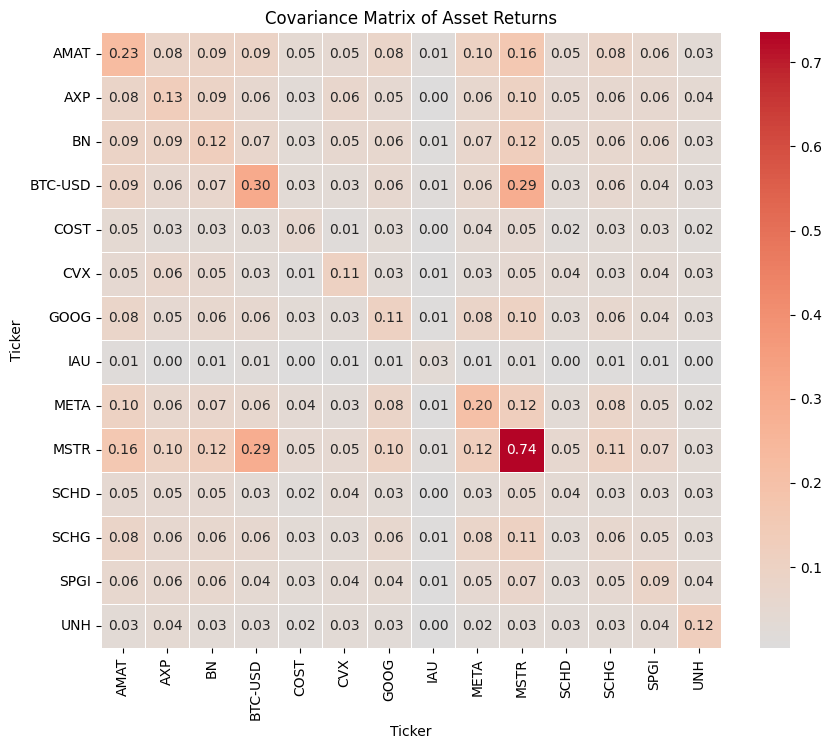

In [3]:
cov_matrix = returns.cov() * 252

plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Covariance Matrix of Asset Returns')
plt.show()

## 4. Correlation Matrix
Normalized covariance — easier to interpret across assets.

$$\rho_{ij} = \frac{\Sigma_{ij}}{\sigma_i \sigma_j}$$

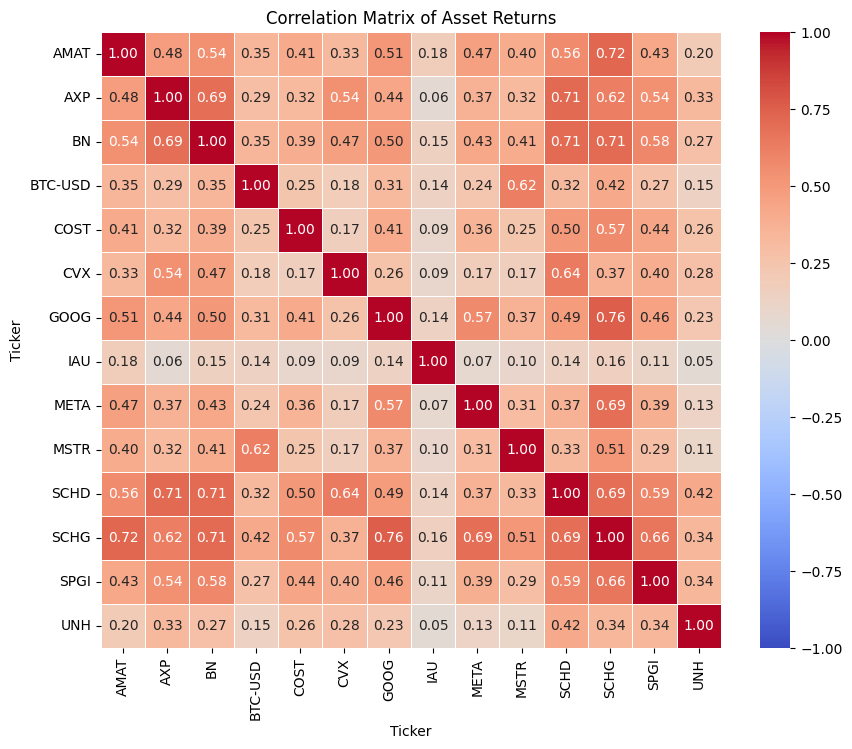

In [4]:
corr_matrix = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title('Correlation Matrix of Asset Returns')
plt.show()

## 5. Efficient Frontier
Plot the set of optimal portfolios for a given level of risk.

$$\min_w \quad w^\top \Sigma w$$

$$\text{subject to} \quad w^\top \mu = \mu^* \quad \text{and} \quad \sum w_i = 1$$

Solving for target return: 0.1328
Solving for target return: 0.1417
Solving for target return: 0.1506
Solving for target return: 0.1595
Solving for target return: 0.1685
Solving for target return: 0.1774
Solving for target return: 0.1863
Solving for target return: 0.1953
Solving for target return: 0.2042
Solving for target return: 0.2131
Solving for target return: 0.2221
Solving for target return: 0.2310
Solving for target return: 0.2399
Solving for target return: 0.2488
Solving for target return: 0.2578
Solving for target return: 0.2667
Solving for target return: 0.2756
Solving for target return: 0.2846
Solving for target return: 0.2935
Solving for target return: 0.3024
Solving for target return: 0.3114
Solving for target return: 0.3203
Solving for target return: 0.3292
Solving for target return: 0.3381
Solving for target return: 0.3471
Solving for target return: 0.3560
Solving for target return: 0.3649
Solving for target return: 0.3739
Solving for target return: 0.3828
Solving for ta

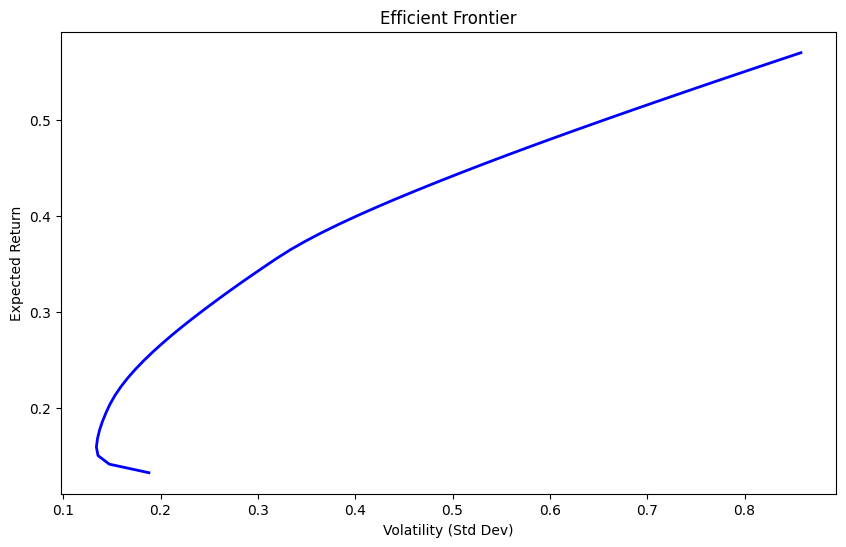

In [5]:
import numpy as np
from scipy.optimize import minimize

expected_returns = returns.mean() * 252

n = len(tickers)
results = []

for target_return in np.linspace(expected_returns.min(), expected_returns.max(), 50):
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, r=target_return: w @ expected_returns.values - r}
    ]
    bounds = [(0, 1)] * n
    w0 = np.ones(n) / n

    result = minimize(
        lambda w: w @ cov_matrix.values @ w,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        vol = np.sqrt(result.fun)
        results.append((vol, target_return))

vols, rets = zip(*results)

plt.figure(figsize=(10, 6))
plt.plot(vols, rets, 'b-', linewidth=2)
plt.xlabel('Volatility (Std Dev)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.show()

## 6. Maximum Sharpe Portfolio

Find the portfolio weights that maximize return per unit of risk.
$$\max_w \quad \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma w}}$$

In [6]:
from src.optimize import max_sharpe

weights = max_sharpe(expected_returns, cov_matrix)
print(dict(zip(tickers, weights.round(4))))

ModuleNotFoundError: No module named 'src'